In [8]:
import os

In [2]:
print(os.getcwd())

C:\Users\sivab\handwritting\handwritten_datasets\train\a


In [2]:
import cv2

In [3]:
import matplotlib.pyplot as plt

In [5]:
image = cv2.imread("image_130.jpg")

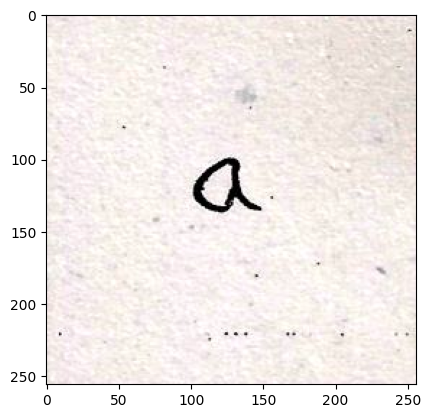

In [6]:
plt.imshow(image)

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

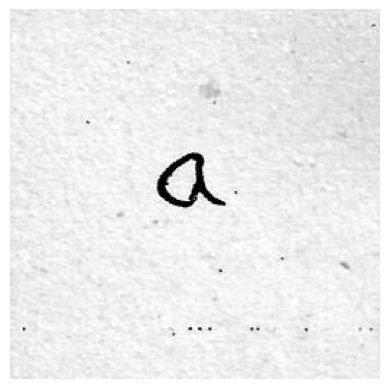

In [7]:
gray_image = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
plt.imshow(gray_image,cmap ='gray')
plt.axis('off')

In [13]:
_,threshold = cv2.threshold(
    gray_image,
    130,
    255,
    cv2.THRESH_BINARY
)

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

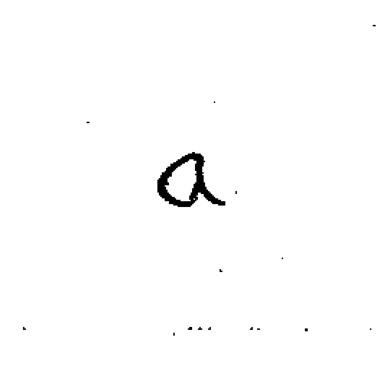

In [14]:
plt.imshow(threshold,cmap='gray')
plt.axis('off')

In [16]:
contours, _ = cv2.findContours(
    cv2.bitwise_not(threshold),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

In [17]:
print(len(contours))

16


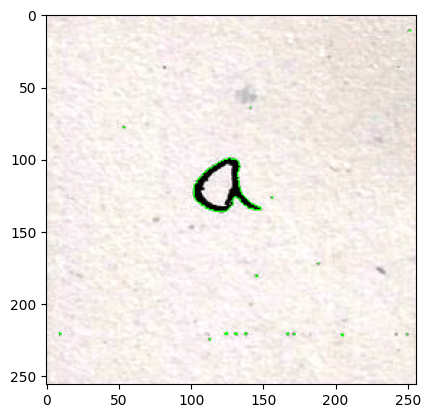

In [21]:
drawing_image = image.copy()
cv2.drawContours(
    drawing_image,
    contours,
    -1,
    (0,255,0),
    1
)
plt.imshow(drawing_image,cmap='gray')

In [30]:
for contour in contours:
    area = cv2.contourArea(contour)
    print(area)

0.0
0.0
1.0
0.0
0.5
0.5
1.0
1.5
0.5
0.5
0.0
0.0
915.0
0.0
0.0
0.0


In [33]:
max_area =0
final_contour =None
for contour in contours:
    area = cv2.contourArea(contour) 
    if area > max_area:
        max_area = area
        final_contour = contour

In [37]:
x,y,w,h = cv2.boundingRect(final_contour)

In [38]:
print('dimensions :',x,y,w,h)

dimensions : 102 99 47 38


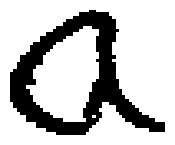

In [40]:
character = threshold[y:y+h, x:x+w]
plt.figure(figsize=(2, 2))
plt.imshow(character, cmap="gray")
plt.axis("off")
plt.show()

In [41]:
character.shape

(38, 47)

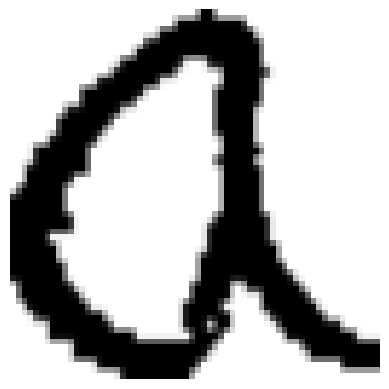

In [48]:
resized_img = cv2.resize(character, (64, 64))
plt.imshow(resized_img, cmap="gray")
plt.axis("off")
plt.show()

dimensions : 109 130 45 50


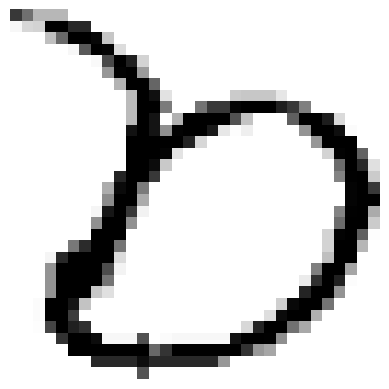

In [4]:
img = cv2.imread('image_106.jpg')
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
_,threshold = cv2.threshold(
    gray,
    127,
    255,
    cv2.THRESH_BINARY
)
contours,_ = cv2.findContours(
    cv2.bitwise_not(threshold),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)
max_area =0
final_contour =None
for contour in contours:
    area = cv2.contourArea(contour) 
    if area > max_area:
        max_area = area
        final_contour = contour
x,y,w,h = cv2.boundingRect(final_contour)
print('dimensions :',x,y,w,h)
character = threshold[y:y+h, x:x+w]
resized_img = cv2.resize(character, (32,32))
plt.imshow(resized_img, cmap="gray")
plt.axis("off")
plt.show()

In [63]:
resized_img.shape

(28, 28)

In [64]:
character.shape

(50, 45)

In [65]:
features = resized_img.flatten()
print(features.shape)

(784,)


Bounding box: 109 130 45 50
Image shape: (28, 28)
Feature shape: (784,)


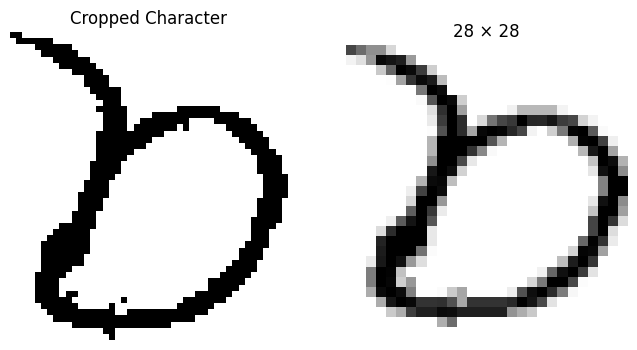

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


img = cv2.imread("image_106.jpg")

# 1. Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


# 2. Threshold
_, threshold = cv2.threshold(
    gray,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)


# 3. Invert for contour detection
binary = cv2.bitwise_not(threshold)


# 4. Find external contours
contours, _ = cv2.findContours(
    binary,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)


# 5. Remove very small noise contours
contours = [
    contour
    for contour in contours
    if cv2.contourArea(contour) > 20
]


# 6. Find bounding boxes of all useful contours
boxes = []

for contour in contours:

    x, y, w, h = cv2.boundingRect(contour)

    boxes.append((x, y, w, h))


# 7. Combine all useful contours into ONE bounding box
if boxes:

    x_min = min(x for x, y, w, h in boxes)
    y_min = min(y for x, y, w, h in boxes)

    x_max = max(x + w for x, y, w, h in boxes)
    y_max = max(y + h for x, y, w, h in boxes)

    x = x_min
    y = y_min
    w = x_max - x_min
    h = y_max - y_min

    # 8. Crop the complete character
    character = threshold[y:y+h, x:x+w]


    # 9. Resize to 28 × 28
    resized_img = cv2.resize(
        character,
        (28, 28),
        interpolation=cv2.INTER_AREA
    )


    # 10. Flatten for KNN
    features = resized_img.flatten()


    print("Bounding box:", x, y, w, h)
    print("Image shape:", resized_img.shape)
    print("Feature shape:", features.shape)


    # Display
    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(character, cmap="gray")
    plt.title("Cropped Character")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(resized_img, cmap="gray")
    plt.title("28 × 28")
    plt.axis("off")

    plt.show()

else:
    print("No character found")

In [15]:
def preprocess_image(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, threshold = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    binary = cv2.bitwise_not(threshold)
    contours, _ = cv2.findContours(
        binary,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )
    contours = [
        contour for contour in contours
        if cv2.contourArea(contour) > 20
    ]
    if not contours:
        return None
    boxes = [cv2.boundingRect(contour) for contour in contours]
    x_min = min(x for x, y, w, h in boxes)
    y_min = min(y for x, y, w, h in boxes)
    x_max = max(x + w for x, y, w, h in boxes)
    y_max = max(y + h for x, y, w, h in boxes)
    character = threshold[y_min:y_max, x_min:x_max]
    resized_img = cv2.resize(
        character,
        (32, 32),
        interpolation=cv2.INTER_AREA
    )
    return resized_img.flatten()

In [9]:
print(os.getcwd())
print(os.path.exists("handwritten_datasets"))
print(os.path.exists("handwritten_datasets/train"))

C:\Users\sivab\handwritting\handwritten_datasets\train\a
False
False


In [72]:
train_path = r"..\..\.."
print(os.path.abspath(train_path))
print(os.listdir(train_path))

C:\Users\sivab\handwritting
['.ipynb_checkpoints', 'ALPHABETS.jpg', 'experiment_on_single_letter.ipynb', 'experiment_on_word.ipynb', 'handwriting.jpeg', 'handwritten_datasets', 'handwritten_templete_matching.ipynb', 'helloworld.jpeg', 'hello_world.jpg', 'letterA.jpg', 'same_fonttext_templete_matching.ipynb', 'templeteA.jpg', 'testing.jpg', 'Untitled.ipynb']


In [10]:
train_path = r"C:\Users\sivab\handwritting\handwritten_datasets\train"

print("Exists:", os.path.exists(train_path))
print("Path:", train_path)

Exists: True
Path: C:\Users\sivab\handwritting\handwritten_datasets\train


In [11]:
print(os.listdir(train_path))

['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [16]:
X = []
y = []
for letter in os.listdir(train_path):
    letter_path = os.path.join(train_path, letter)
    for image_name in os.listdir(letter_path):
        image_path = os.path.join(letter_path, image_name)
        features = preprocess_image(image_path)
        if features is not None:
            X.append(features)
            y.append(letter)

In [17]:
X = np.array(X)
y = np.array(y)

In [18]:
X.shape

(13168, 1024)

In [19]:
y.shape

(13168,)

In [20]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X, y)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [21]:
test_path = r"C:\Users\sivab\handwritting\handwritten_datasets\test"
X_test = []
y_test = []
for letter in os.listdir(test_path):
    letter_path = os.path.join(test_path, letter)
    for image_name in os.listdir(letter_path):
        image_path = os.path.join(letter_path, image_name)
        features = preprocess_image(image_path)
        if features is not None:
            X_test.append(features)
            y_test.append(letter)

In [22]:
X_test = np.array(X_test)
y_test = np.array(y_test)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_test: (1792, 1024)
y_test: (1792,)


In [23]:
y_pred = knn.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score

In [25]:
print(accuracy_score(y_test,y_pred))

0.68359375


In [26]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           a       0.70      0.85      0.77        68
           b       0.57      0.74      0.64        72
           c       0.55      0.82      0.66        67
           d       0.62      0.79      0.70        57
           e       0.73      0.75      0.74        64
           f       0.63      0.73      0.68        78
           g       0.80      0.69      0.74        64
           h       0.75      0.68      0.72        76
           i       0.64      0.73      0.69        67
           j       0.77      0.67      0.72        79
           k       0.75      0.68      0.71        66
           l       0.66      0.75      0.70        55
           m       0.90      0.71      0.79        65
           n       0.73      0.65      0.69        63
           o       0.87      0.78      0.82        86
           p       0.75      0.73      0.74        59
           q       0.87      0.67      0.76        72
           r       0.62    

In [93]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def preprocess_text(image_path):

    img = cv2.imread(image_path)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    _, threshold = cv2.threshold(
        gray,
        90,
        255,
        cv2.THRESH_BINARY
    )

    binary = cv2.bitwise_not(threshold)

    contours, _ = cv2.findContours(
        binary,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    contours = [
        contour
        for contour in contours
        if cv2.contourArea(contour) > 30
    ]

    boxes = []

    for contour in contours:

        x, y, w, h = cv2.boundingRect(contour)

        boxes.append([x, y, w, h])


    merged = []

    used = [False] * len(boxes)

    for i in range(len(boxes)):

        if used[i]:
            continue

        x1, y1, w1, h1 = boxes[i]

        current = [x1, y1, w1, h1]

        for j in range(len(boxes)):

            if i == j or used[j]:
                continue

            x2, y2, w2, h2 = boxes[j]

            center1 = x1 + w1 / 2
            center2 = x2 + w2 / 2

            horizontal_distance = abs(center1 - center2)

            bottom1 = y1 + h1
            top2 = y2

            bottom2 = y2 + h2
            top1 = y1

            vertical_gap = min(
                abs(top2 - bottom1),
                abs(top1 - bottom2)
            )

            if (
                horizontal_distance < max(w1, w2)
                and vertical_gap < 40
            ):

                x_min = min(current[0], x2)
                y_min = min(current[1], y2)

                x_max = max(
                    current[0] + current[2],
                    x2 + w2
                )

                y_max = max(
                    current[1] + current[3],
                    y2 + h2
                )

                current = [
                    x_min,
                    y_min,
                    x_max - x_min,
                    y_max - y_min
                ]

                used[j] = True

        merged.append(current)
        used[i] = True


    boxes = sorted(merged, key=lambda box: box[0])


    contour_image = img.copy()

    for x, y, w, h in boxes:

        cv2.rectangle(
            contour_image,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            1
        )

        cv2.putText(
            contour_image,
            'C',
            (x, y - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 0),
            2
        )


    plt.figure(figsize=(10, 10))
    plt.imshow(
        cv2.cvtColor(contour_image, cv2.COLOR_BGR2RGB)
    )
    plt.title(f"Characters: {len(boxes)}")
    plt.axis("off")
    plt.show()


    features = []
    characters = []

    for x, y, w, h in boxes:

        character = threshold[y:y+h, x:x+w]

        resized = cv2.resize(
            character,
            (32, 32),
            interpolation=cv2.INTER_AREA
        )

        feature = resized.flatten()

        features.append(feature)
        characters.append(resized)


    return features, characters, boxes

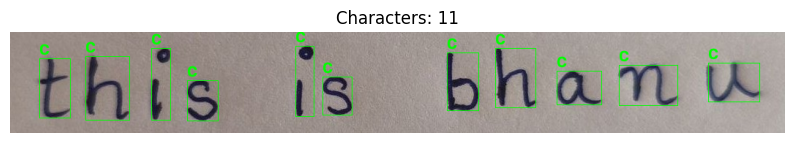

In [94]:
features, characters, boxes = preprocess_text(
    r"C:\Users\sivab\handwritting\me.jpg"
)

In [95]:
print("Characters detected:", len(features))

Characters detected: 11


In [96]:
predictions = knn.predict(np.array(features))
print(predictions)

['p' 'h' 'i' 's' 'i' 's' 'b' 'h' 'a' 'n' 'u']


In [98]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)

svm_model.fit(X, y)

,C,10
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [99]:
y_pred_sv = svm_model.predict(X_test)

In [101]:
print(accuracy_score(y_test,y_pred_sv))

0.8292410714285714


In [102]:
predictions = svm_model.predict(np.array(features))
print(predictions)

['b' 'h' 'i' 's' 'i' 's' 'b' 'h' 'a' 'n' 'u']


In [103]:
print(classification_report(y_test,y_pred_sv))

              precision    recall  f1-score   support

           a       0.91      0.85      0.88        68
           b       0.86      0.85      0.85        72
           c       0.84      0.81      0.82        67
           d       0.92      0.86      0.89        57
           e       0.91      0.80      0.85        64
           f       0.97      0.91      0.94        78
           g       0.90      0.95      0.92        64
           h       0.93      0.89      0.91        76
           i       0.69      0.93      0.79        67
           j       0.97      0.82      0.89        79
           k       0.92      0.89      0.91        66
           l       0.90      0.85      0.88        55
           m       0.93      0.82      0.87        65
           n       0.86      0.81      0.84        63
           o       0.99      0.83      0.90        86
           p       0.93      0.90      0.91        59
           q       0.95      0.96      0.95        72
           r       0.73    

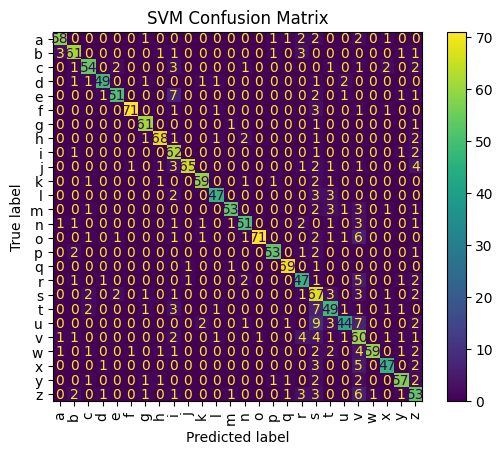

In [104]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_sv,
    xticks_rotation="vertical"
)

plt.title("SVM Confusion Matrix")
plt.show()

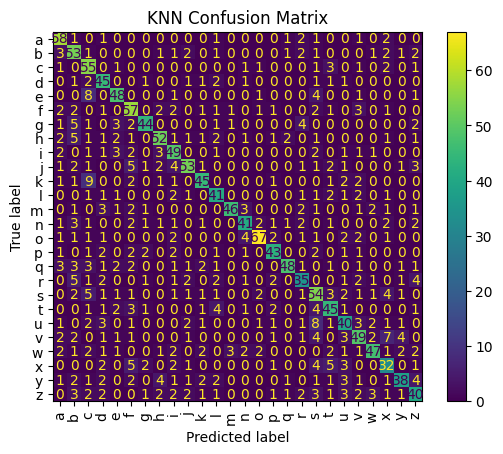

In [105]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation="vertical"
)

plt.title("KNN Confusion Matrix")
plt.show()

Feature-based machine learning provided a significant improvement over direct template and contour-based matching. Among the evaluated classifiers, SVM achieved higher recognition performance than KNN on the handwritten-character dataset. However, recognition of completely unseen handwriting should be evaluated separately because dataset performance does not necessarily represent real-world handwriting performance.